



# NEURAL NETWORK
designed according to given schemiatic

importing out dependencies

In [68]:
import numpy as np
import pandas as pd
import os
import random

import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from torch.utils.data.dataloader import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import pickle
import matplotlib.pyplot as plt




Seeding and defining GPU device

In [69]:
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

seed_everything()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


defining our hyperparameters

In [70]:
learning_rate= 0.001
epochs= 20

fetch the FMNIST dataset from openml dataset library

In [71]:



from torchvision import datasets, transforms

# Separate explicit endpoints for the original splits
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform = [transforms.ToTensor()])
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform = [transforms.ToTensor()])
# --- ADDED LINES ---
# Extracting and scaling the training features and labels
x_train = train_dataset.data.float() / 255.0
y_train = train_dataset.targets
x_test = test_dataset.data.float()/255.0
y_test = test_dataset.targets

# --- ADDED LINES FOR FLATTENING ---
# Flatten from [60000, 28, 28] to [60000, 784]
x_train = x_train.view(x_train.size(0), -1)
x_test  = x_test.view(x_test.size(0), -1)

x_test.shape



torch.Size([10000, 784])

OneHot encoding the Ydata

In [72]:
'''technically, we do not need to onehot encode our ydata as the loss function
CrossEntropyLoss accepts target lables encoded in class form AND onehot encoded
form. I am choosing to OneHotEncode because we may want to perform label
smoothing or other transforms later on.'''

y_train = F.one_hot(y_train, num_classes=10)
y_test  = F.one_hot(y_test, num_classes=10)

Defining and Loading a dataloader class

In [73]:
from torch.utils.data.dataloader import DataLoader

class data_loader(torch.utils.data.Dataset):
  def __init__(self, x_tensor, y_tensor):
    self.x= x_tensor
    self.y= y_tensor

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx]

#creating a train dataset object, test dataset object

train_data= data_loader(x_train, y_train)
test_data = data_loader(x_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)


In [74]:
x_train.shape

torch.Size([60000, 784])

NEURAL NETWORK CLASS

In [75]:
import torch.nn as nn
import torch.nn.functional as F
class neural_net(nn.Module):
  def __init__(self, num_of_features, num_of_output_classes):
    super().__init__()


    self.fc1 = nn.Linear(784, 16)
    self.left_fc1 = nn.Linear(16, 8)
    self.left_fc2 = nn.Linear(8, 8)

    self.right_fc1 = nn.Linear(16, 12)
    self.right_fc2 = nn.Linear(12, 8)

    self.output_layer = nn.Linear(16, 10)


  def forward(self,x):
    x = F.relu(self.fc1(x))
    xleft = F.relu(self.left_fc1(x))
    xleft2 = F.relu(self.left_fc2(xleft))
    xleft = xleft + xleft2
    xright = F.relu(self.right_fc1(x))
    xright = F.relu(self.right_fc2(xright))

    combination = torch.cat((xleft, xright), dim=1)

    out = self.output_layer(combination)
    return out

model =neural_net(784, 10)


In [76]:

lossfn= nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=learning_rate)


training loop

In [77]:
def compute_test_accuracy(test_loader, model):
  total =0
  correct =0

  with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      batch_features.shape
      output= model(batch_features)
      _, predicted =torch.max(output, 1)

      # Convert one-hot encoded batch_labels to class indices for comparison
      correct+=(predicted==torch.argmax(batch_labels, 1)).sum().item()
      total += batch_labels.shape[0]


  accuracy= correct/total
  print(f"Accuracy: {accuracy}")
  return accuracy

In [78]:
epoch_losses = []
testing_accuracy = [] # List to store average loss per epoch
model.eval()

for epoch in range(epochs):
  testing_accuracy.append(compute_test_accuracy(test_loader, model))
  total_epoch_loss= 0
  for batch_features, batch_labels in train_loader:
    optimizer.zero_grad()
    outputs= model(batch_features)
    loss= lossfn(outputs, batch_labels.float())
    total_epoch_loss+= loss.item()
    #backward pass to calculate all the gradients
    loss.backward()
    #updating params.
    optimizer.step()
  average_loss= total_epoch_loss/150
  epoch_losses.append(average_loss)




Accuracy: 0.1
Accuracy: 0.7663
Accuracy: 0.8205
Accuracy: 0.829
Accuracy: 0.8384
Accuracy: 0.8408
Accuracy: 0.8438
Accuracy: 0.8466
Accuracy: 0.8484
Accuracy: 0.848
Accuracy: 0.8502
Accuracy: 0.8416
Accuracy: 0.8453
Accuracy: 0.8513
Accuracy: 0.8513
Accuracy: 0.8406
Accuracy: 0.8527
Accuracy: 0.8548
Accuracy: 0.8436
Accuracy: 0.8565


plotting loss vs epoch

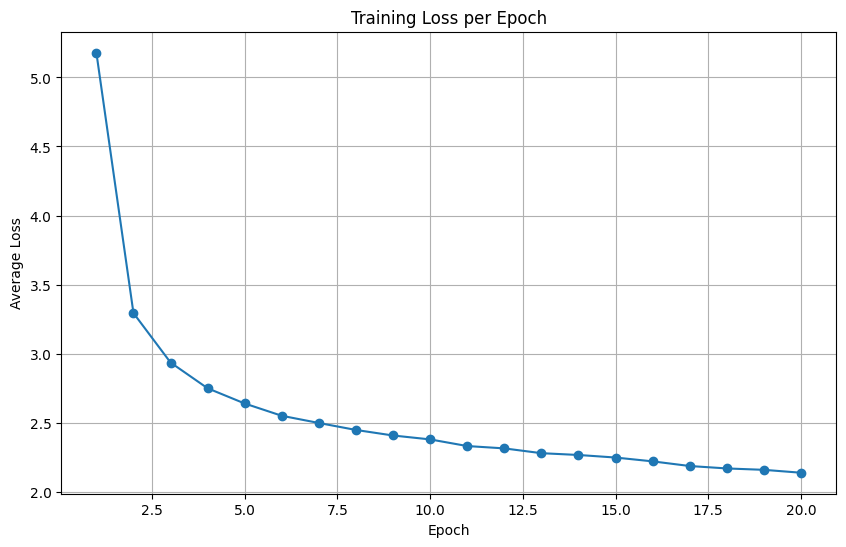

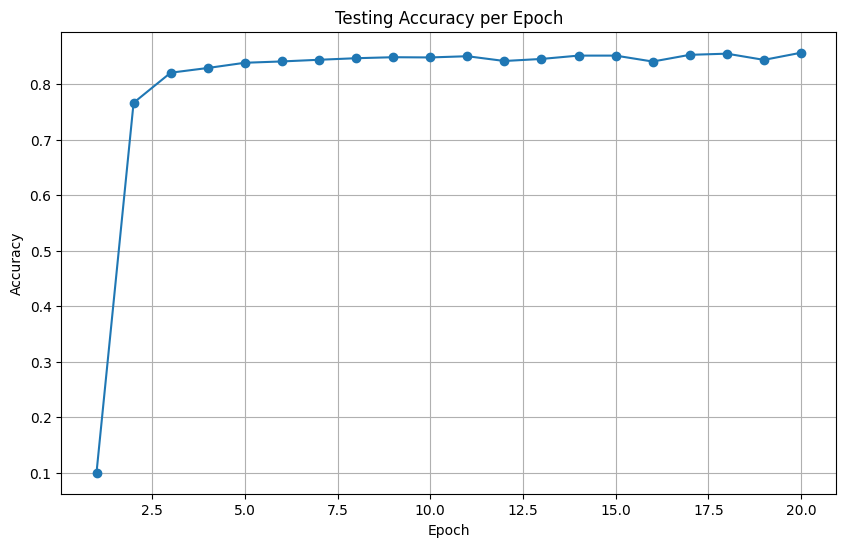

In [79]:
#plotting the epoch losses:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o', linestyle='-')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), testing_accuracy, marker='o', linestyle='-')
plt.title('Testing Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

pushing testing data into file

In [80]:

# Convert predictions to a pandas DataFrame to save it to file
submission_df = pd.DataFrame({'ImageId': range(1, len(predicted) + 1), 'Label': predicted.numpy()})

# Save the DataFrame to a CSV file
submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)
print("File successfully created: ")
print(submission_df.head())

File successfully created: 
   ImageId  Label
0        1      9
1        2      9
2        3      9
3        4      9
4        5      9


PUSHING MODEL INTO BINARY FILE USING PICKLE

In [81]:
import pickle

# Define the filename for your saved weights
weights_filename = 'model_weights.pkl'

# Save the model's state_dict using pickle
with open(weights_filename, 'wb') as f:
    pickle.dump(model.state_dict(), f)
